# Bayes' Rule: The Medical Test Problem

A disease affects 1% of people. The test catches 90% of sick people, but also gives a false alarm for 9% of healthy people. If you test positive, what is the chance you are really sick?

I answered it three ways: by counting 1,000 people, by simulating 100,000 people, and with Bayes' formula.

**Key findings**
- Answer: about 9%, not 90%.
- The disease is rare, so false alarms from healthy people outnumber real cases.
- The same test gives about 91% when half the population is sick. A positive result depends on how common the disease is.

In [1]:
import numpy as np

n_people = 100000
sick = np.random.random(n_people) < 0.01

print(sick[:10])
print(sick.sum())

[False False False False False False False False False False]
993


In [2]:
test_roll = np.random.random(n_people)
positive = np.where(sick, test_roll < 0.90, test_roll < 0.09)

print(positive.sum())

9820


In [3]:
true_positive = (sick & positive).sum()

print("Sick:", sick.sum())
print("Sick and positive:", true_positive)
print("P(sick/positive):", true_positive / positive.sum())

Sick: 993
Sick and positive: 893
P(sick/positive): 0.09093686354378819


In [4]:
p_sick = 0.01
p_pos_given_sick = 0.90
p_pos_given_healthy = 0.09

p_positive = p_pos_given_sick * p_sick + p_pos_given_healthy * (1 - p_sick)
p_sick_given_pos = p_pos_given_sick * p_sick / p_positive

print("Formula answer:", p_sick_given_pos)

Formula answer: 0.09174311926605506


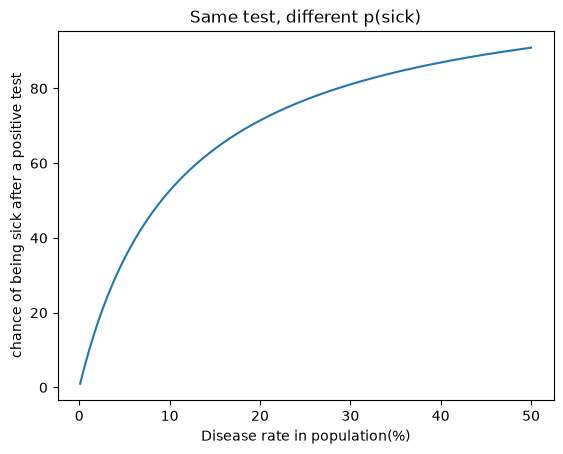

In [5]:
import matplotlib.pyplot as plt

sick_rates = np.linspace(0.001, 0.5, 200)
p_positive = p_pos_given_sick * sick_rates + p_pos_given_healthy * (1 - sick_rates)
p_sick_given_positive = (p_pos_given_sick * sick_rates) / p_positive

plt.plot(sick_rates* 100, p_sick_given_positive * 100)
plt.xlabel("Disease rate in population(%)")
plt.ylabel("chance of being sick after a positive test")
plt.title("Same test, different p(sick)")
plt.savefig("bayes_curve.png", dpi=150)
plt.show()